# (노트) CNN 기초내용

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

In [129]:
import torch
import matplotlib.pyplot as plt 

### 컨볼루션 

#### 컨볼루션 연산 

`-` 아래는 (5,5) 이미지에 (3,3)커널을 적용하여 컨볼루션을 수행한 결과이다. 

![](2021-11-02-conv.png)

- https://arxiv.org/abs/1603.07285

#### 기본기능

In [139]:
conv= torch.nn.Conv2d(1,2,2,bias=False)

`-` 필터값확인

In [140]:
conv.weight.data

tensor([[[[-0.2597, -0.3378],
          [ 0.0704,  0.0201]]],


        [[[-0.2661,  0.1038],
          [-0.4279,  0.4504]]]])

`-` 필터값을 원하는것으로 변경 

In [148]:
conv.weight.data=torch.Tensor([[[[0.25,0.25],
                                 [0.25,0.25]]],
                               [[[-1.0,1.0],
                                 [-1.0,1.0]]]])

- 첫번째는 평균필터, 두번째는 엣지검출필터

In [170]:
conv.weight

Parameter containing:
tensor([[[[ 0.2500,  0.2500],
          [ 0.2500,  0.2500]]],


        [[[-1.0000,  1.0000],
          [-1.0000,  1.0000]]]], requires_grad=True)

`-` 입력데이터 생성 (단순한 흑백대비)

In [181]:
x=torch.Tensor([[.1,.1,.1,.0,.0,.0],
                [.1,.1,.1,.0,.0,.0],
                [.1,.1,.1,.0,.0,.0],
                [.1,.1,.1,.0,.0,.0],
                [.1,.1,.1,.0,.0,.0],
                [.1,.1,.1,.0,.0,.0]]).reshape(1,1,6,6)

In [182]:
x

tensor([[[[0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000],
          [0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000],
          [0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000],
          [0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000],
          [0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000],
          [0.1000, 0.1000, 0.1000, 0.0000, 0.0000, 0.0000]]]])

`-` 입력이미지 

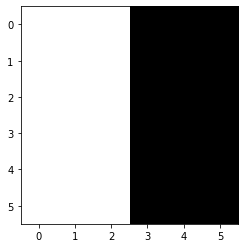

In [183]:
plt.imshow(x.squeeze(),cmap='gray')

In [184]:
conv(x)

tensor([[[[ 0.1000,  0.1000,  0.0500,  0.0000,  0.0000],
          [ 0.1000,  0.1000,  0.0500,  0.0000,  0.0000],
          [ 0.1000,  0.1000,  0.0500,  0.0000,  0.0000],
          [ 0.1000,  0.1000,  0.0500,  0.0000,  0.0000],
          [ 0.1000,  0.1000,  0.0500,  0.0000,  0.0000]],

         [[ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000]]]],
       grad_fn=<ThnnConv2DBackward0>)

In [185]:
conv(x)[0][0],conv(x)[0][1]

(tensor([[0.1000, 0.1000, 0.0500, 0.0000, 0.0000],
         [0.1000, 0.1000, 0.0500, 0.0000, 0.0000],
         [0.1000, 0.1000, 0.0500, 0.0000, 0.0000],
         [0.1000, 0.1000, 0.0500, 0.0000, 0.0000],
         [0.1000, 0.1000, 0.0500, 0.0000, 0.0000]], grad_fn=<SelectBackward0>),
 tensor([[ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -0.2000,  0.0000,  0.0000]],
        grad_fn=<SelectBackward0>))

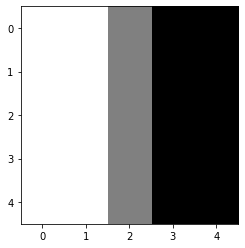

In [186]:
plt.imshow(conv(x)[0][0].data,cmap='gray')

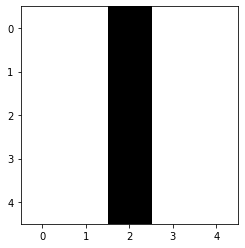

In [187]:
plt.imshow(conv(x)[0][1].data,cmap='gray')

`-` 요약 

- 필터의 계수에 따라서 엣지를 검출하는 필터가 만들어지기도 하고, 스무딩을 하는 필터가 만들어지기도 한다. 
- 이들을 조합하면 다양한 조합이 가능하다. (엣지를 검출하고 스무딩을 한다든지) 


#### 스트라이드, 패딩

`-` 패딩: 이미지의 가장자리에 적당한 값(예를들면 0)을 넣어 컨볼루션 연산이후에도 이미지의 크기가 줄어들지 않도록 방지함

`-` 스트라이드: 윈도우가 1칸씩 이동하는것이 아니라 2~3칸씩 이동함

`-` 구글에서 이미지로 학습해 볼것 
- https://medium.com/analytics-vidhya/convolution-padding-stride-and-pooling-in-cnn-13dc1f3ada26

### maxpooling 

`-` 왜 맥스풀링인가? (차원축소)

`-` 평균이 아니라 max를 쓴 이유는? 평균보다 나을것 같아서..

`-` 최근에는 쓰지 않는 추세

### CNN 아키텍처의 표현방법 

`-` 아래와 같이 아키텍처형태로 주로 표현하고 굳이 이미지를 그리지는 않음 (출처: 위키피디아)

![](https://upload.wikimedia.org/wikipedia/commons/thumb/c/cc/Comparison_image_neural_networks.svg/2560px-Comparison_image_neural_networks.svg.png)

### 배치정규화 (아키텍처 레벨의 컨트롤임) 

`-` 원래 목적은 최적화의 개선으로 개발된 방법이다. 역전파에 의해 발생하는 2~3차 사이드 이펙을 캔슬한다. (미분값을 잘 계산하기 위한 알고리즘) 

`-` 하지만 부수적으로 과적합을 피하는 효과도 있다 (그래서 종종 드랍아웃을 쓸 필요가 없어진다) 

`-` 생각보다 어려운 개념이다. 그냥 이런것이 있다는 것 정도만 알아둘 것. 

### discussion about CNN 

`-` 격자형태로 배열된 자료를 처리하는데 특화된 신경망이다. 
- 시계열 (1차원 격자), 이미지 (2차원 격자)

`-` 실제응용에서 엄청난 성공을 거두었다. 

`-` 이름의 유래는 컨볼루션이라는 수학적 연산을 사용하기 때문이다. 
- 컨볼루션은 조금 특별한 선형연산이다. 

`-` 신경과학의 원리가 심층학습에 영향을 미친 사례이다. 

#### 모티브 

`-` 희소성 + 매개변수공유 
- 다소 철학적인 모티브임 
- 희소성: 이미지를 분석하여 특징을 뽑아낼때 부분부분의 특징만 뽑으면 된다는 의미 (locally compact basis), local linear regression 
- 매개변수공유: 한채널에는 하나의 역할을 하는 커널을 설계하면 된다는 의미 (스무딩이든 엣징이든). 즉 어떤 지역은 스무딩, 어떤 지역은 엣징을 할 필요 없이 한채널에서는 스무딩, 한채널에서는 엣징을 하고 여러채널을 조합해서 이해하면 된다는 것  


`-` 당연한 소리같은데요, 파라메터 감소효과가 엄청납니다. 

(예시) (1,6,6) $\to$ (2,5,5) 

- MLP 방식이라면 $36\times 50$ 의 차원을 가진 매트릭스가 필요함  
- CNN 은 8개 

(예시) (3,224,224) $\to$ (16,224,224) 

#### 신경망의 구조

`-` 콘볼루션 - 활성화 - 풀링 

`-` 풀링: 요약의 의미 
- 요약은 굳이 왜하냐고? 아니 결국 요약은 해야한다. 어차피 결국 $y$는 0 or 1 이어야 하니까!
- 요약 하나도 안하고 있다가 나중에 한번에 하려면 힘들어요 